# AFD-CNN Fall Detection on Actigraph Signals (2026-03-18)

This notebook applies the **AFD-CNN** fall-detection model to four-limb Actigraph recordings
from the **2026-03-18** session, using the activity windows defined in
`Walking detection libraries & Actigraphs signal.ipynb` (cell 20).

Pipeline overview:
1. Load raw 64 Hz Actigraph data for four limbs (RW, LW, RA, LA)
2. Compute the four-limb mean as a lumbar proxy
3. Use the three activity windows from the signals notebook to restrict analysis
4. Run **SKDH** `PredictGaitLumbarLgbm` within each window to detect walking bouts
5. Scan **all activity window timestamps** with a sliding AFD-CNN window
   (200 samples @ 100 Hz = 2 s, step = 25 samples = 0.25 s)
6. Visualise predictions per activity and summarise fall-alert rates

Source data: `/home/ubuntu/git/gait_analysis/Walkin Actigraphs tests/`  
AFD-CNN model: `/home/ubuntu/git/FD-CNN/model/model.ckpt`

## 0. Setup: imports

In [1]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from math import gcd
from scipy.signal import resample_poly

# scikit-digital-health (pre-installed in the fd-cnn venv)
import skdh
from skdh.context import PredictGaitLumbarLgbm

print('skdh version:', skdh.__version__)
print('numpy version:', np.__version__)

skdh version: 0.17.9
numpy version: 2.4.4


## 1. Load Actigraph data — 2026-03-18 session

In [2]:
BASE_DIR = Path('/home/ubuntu/git/gait_analysis/Walkin Actigraphs tests')

def load_acti_data(base_dir, fname):
    """
    Load a raw Actigraph CSV file and return a clean DataFrame.

    - Skips '#'-prefixed metadata header lines.
    - Computes vector magnitude (acc_magnitude) from all accelerometer axes.
    - Aliases axes as 'x', 'y', 'z'.
    - Parses 'Timestamp UTC' to timezone-aware datetime.
    - Builds 'seconds_elapsed' from t0=0; adds sub-second correction at 64 Hz.
    """
    df = pd.read_csv(base_dir / fname, comment='#', skip_blank_lines=True)
    df.columns = [c.strip() for c in df.columns]

    df['acc_magnitude'] = np.sqrt((df.iloc[:, 2:] ** 2).sum(axis=1))
    df['x'] = df['Accelerometer X']
    df['y'] = df['Accelerometer Y']
    df['z'] = df['Accelerometer Z']

    df['Timestamp UTC'] = pd.to_datetime(df['Timestamp UTC'], utc=True, errors='coerce')

    t0 = df['Timestamp UTC'].dropna().iloc[0]
    df['seconds_elapsed'] = (df['Timestamp UTC'] - t0).dt.total_seconds().astype(float)

    # Sub-second correction: file timestamps are per-second; reconstruct intra-second
    # position from sample index modulo 64 (sampling rate = 64 Hz).
    sec_correction = np.arange(len(df)) % 64 / 64.0
    df['seconds_elapsed'] += sec_correction
    df['Timestamp UTC'] += pd.to_timedelta(sec_correction, unit='s')

    return df


# Load all four limbs for the 2026-03-18 session
df_RW = load_acti_data(BASE_DIR, 'EALS-DATA-004_STM2D48232042_2026-03-18_12_00_00_AM_1.CSV')
df_LW = load_acti_data(BASE_DIR, 'EALS-DATA-002_STM2D48230423_2026-03-18_05_46_04_PM_1.CSV')
df_RA = load_acti_data(BASE_DIR, 'EALS-DATA-001_STM2D48230106_2026-03-18_05_46_02_PM_1.CSV')
df_LA = load_acti_data(BASE_DIR, 'EALS-DATA-003_STM2D48232727_2026-03-18_05_45_58_PM_1.CSV')

for lbl, df in [('RW', df_RW), ('LW', df_LW), ('RA', df_RA), ('LA', df_LA)]:
    print(f'{lbl}: {len(df):,} samples | '
          f'{df["Timestamp UTC"].iloc[0]} \u2192 {df["Timestamp UTC"].iloc[-1]}')

RW: 7,643,264 samples | 2026-03-18 00:00:00+00:00 → 2026-03-19 13:07:59.984375+00:00
LW: 4,440,512 samples | 2026-03-18 17:46:05+00:00 → 2026-03-19 13:06:28.984375+00:00
RA: 4,404,096 samples | 2026-03-18 17:46:03+00:00 → 2026-03-19 12:56:09.984375+00:00
LA: 4,433,216 samples | 2026-03-18 17:45:59+00:00 → 2026-03-19 13:04:19.984375+00:00


## 2. Activity windows (from signals notebook cell 20)

In [3]:
# Activity windows from Walking detection libraries & Actigraphs signal.ipynb (cell 20)
# Three broad activity windows from the 2026-03-18 session
classification_windows_2026_03_18 = [
    ['2026-03-18 20:20:00', '2026-03-18 21:00:00'],  # Evening walk
    ['2026-03-18 21:10:00', '2026-03-18 21:40:00'],  # Bicycle
    ['2026-03-18 23:00:00', '2026-03-19 00:10:00'],  # Daily walking
]

classification_tasks_2026_03_18 = [
    'Evening walk',
    'Bicycle',
    'Daily walking',
]

# Build tidy interval DataFrame
task_intervals = pd.DataFrame({
    'start_time': [pd.Timestamp(w[0], tz='UTC') for w in classification_windows_2026_03_18],
    'end_time':   [pd.Timestamp(w[1], tz='UTC') for w in classification_windows_2026_03_18],
    'task':       classification_tasks_2026_03_18,
})

SESSION_START = task_intervals['start_time'].min()
SESSION_END   = task_intervals['end_time'].max()

print(f'Session span: {SESSION_START} \u2192 {SESSION_END}')
print(f'Total activity windows: {len(task_intervals)}')
print(task_intervals[['task', 'start_time', 'end_time']].to_string(index=False))

Session span: 2026-03-18 20:20:00+00:00 → 2026-03-19 00:10:00+00:00
Total activity windows: 3
         task                start_time                  end_time
 Evening walk 2026-03-18 20:20:00+00:00 2026-03-18 21:00:00+00:00
      Bicycle 2026-03-18 21:10:00+00:00 2026-03-18 21:40:00+00:00
Daily walking 2026-03-18 23:00:00+00:00 2026-03-19 00:10:00+00:00


## 3. Four-limb mean (lumbar proxy)

In [4]:
# Average X, Y, Z and acc_magnitude across all four limbs on the shared timestamp grid.
# PredictGaitLumbarLgbm is trained on lumbar-mounted accelerometers; the four-limb mean
# provides a whole-body motion proxy that reduces limb-specific artefacts.

_dfs = {'RW': df_RW, 'LW': df_LW, 'RA': df_RA, 'LA': df_LA}
df_mean = df_LW[['Timestamp UTC']].copy()
for lbl, df in _dfs.items():
    df_mean = df_mean.merge(
        df[['Timestamp UTC', 'acc_magnitude', 'x', 'y', 'z']].rename(columns={
            'acc_magnitude': f'acc_magnitude_{lbl}',
            'x': f'x_{lbl}', 'y': f'y_{lbl}', 'z': f'z_{lbl}',
        }),
        on='Timestamp UTC',
        how='inner',
    )

for col in ['acc_magnitude', 'x', 'y', 'z']:
    df_mean[col] = df_mean[[f'{col}_{lbl}' for lbl in _dfs]].mean(axis=1)

print(f'Four-limb mean: {len(df_mean):,} shared samples')
print(f'Time range: {df_mean["Timestamp UTC"].iloc[0]} \u2192 {df_mean["Timestamp UTC"].iloc[-1]}')

Four-limb mean: 4,165,312 shared samples
Time range: 2026-03-18 18:37:24+00:00 → 2026-03-19 12:56:09.984375+00:00


## 4. Overview plot — acc_magnitude with activity backgrounds

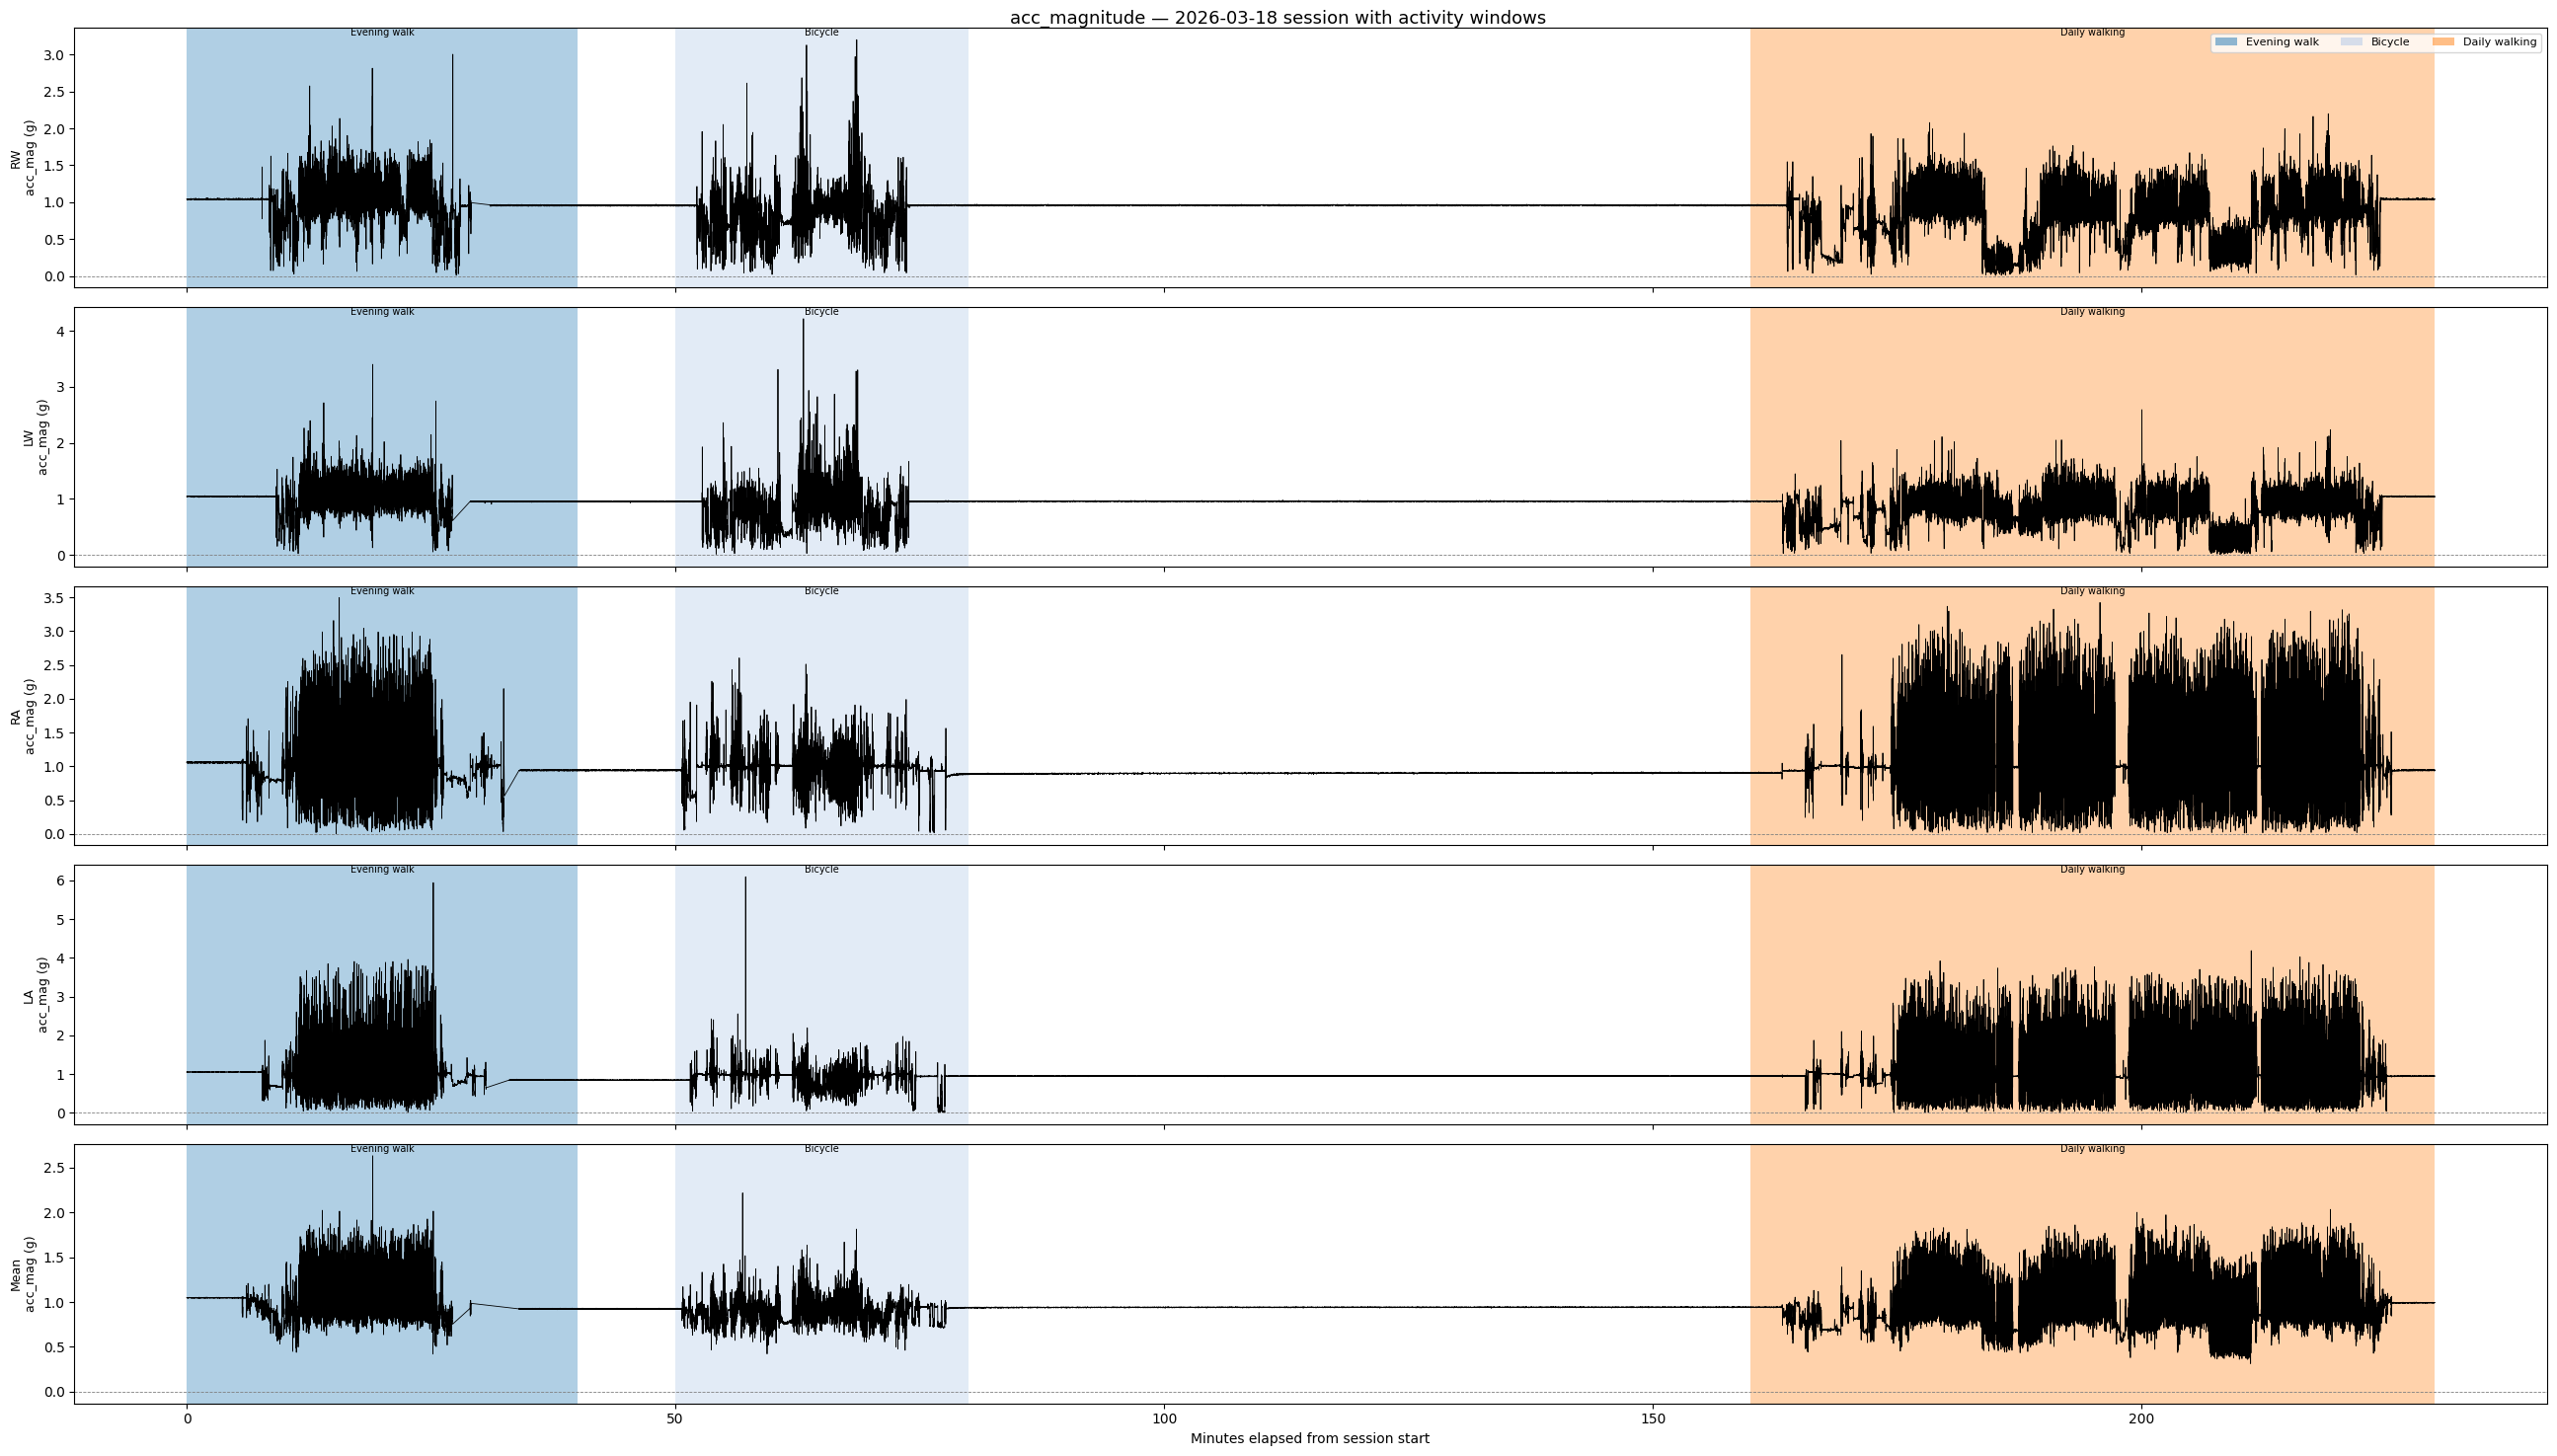

In [5]:
# Colour palette — one colour per unique task
_unique_tasks = list(dict.fromkeys(classification_tasks_2026_03_18))
_palette = list(plt.cm.tab20.colors)
TASK_COLORS = {t: _palette[i % len(_palette)] for i, t in enumerate(_unique_tasks)}

def plot_session_overview(signals_dict, task_intervals, session_start, session_end, title=''):
    """Plot acc_magnitude for each signal with activity-coloured background bands."""
    fig, axes = plt.subplots(len(signals_dict), 1,
                              figsize=(26, 3 * len(signals_dict)), sharex=True)
    if len(signals_dict) == 1:
        axes = [axes]

    for ax, (label, df) in zip(axes, signals_dict.items()):
        plot_df = df[['Timestamp UTC', 'acc_magnitude']].dropna().copy()
        plot_df = plot_df[
            (plot_df['Timestamp UTC'] >= session_start) &
            (plot_df['Timestamp UTC'] <= session_end)
        ].copy()
        if plot_df.empty:
            ax.set_title(f'{label} \u2014 no data')
            continue

        t_ref = plot_df['Timestamp UTC'].iloc[0]
        plot_df['min_elapsed'] = (plot_df['Timestamp UTC'] - t_ref).dt.total_seconds() / 60.0

        for _, row in task_intervals.iterrows():
            s = (row['start_time'] - t_ref).total_seconds() / 60.0
            e = (row['end_time']   - t_ref).total_seconds() / 60.0
            ax.axvspan(s, e, color=TASK_COLORS.get(row['task'], '#cccccc'), alpha=0.35, linewidth=0)
            ax.text((s + e) / 2, 1.0, row['task'],
                    transform=ax.get_xaxis_transform(),
                    ha='center', va='top', fontsize=7, clip_on=True)

        if len(plot_df) > 50_000:
            stride = max(1, len(plot_df) // 50_000)
            plot_df = plot_df.iloc[::stride].copy()

        ax.plot(plot_df['min_elapsed'], plot_df['acc_magnitude'], color='black', lw=0.6)
        ax.axhline(0, color='0.5', ls='--', lw=0.6)
        ax.set_ylabel(f'{label}\nacc_mag (g)', fontsize=9)

    legend_handles = [
        mpatches.Patch(facecolor=TASK_COLORS[t], edgecolor='none', alpha=0.5, label=t)
        for t in _unique_tasks
    ]
    axes[0].legend(handles=legend_handles, loc='upper right', fontsize=8, ncol=3)
    axes[-1].set_xlabel('Minutes elapsed from session start')
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


all_signals = {'RW': df_RW, 'LW': df_LW, 'RA': df_RA, 'LA': df_LA, 'Mean': df_mean}
plot_session_overview(
    all_signals, task_intervals, SESSION_START, SESSION_END,
    title='acc_magnitude \u2014 2026-03-18 session with activity windows',
)

## 5. SKDH gait detection on the full activity window span

In [6]:
FS_ACTI = 64  # Actigraph sampling rate (Hz)


def resolve_time_window(time_window):
    """Convert [t0, tf] strings or Timestamps to UTC-aware pd.Timestamps."""
    if time_window is None:
        return None, None
    t0 = time_window[0] if isinstance(time_window[0], pd.Timestamp) else pd.Timestamp(time_window[0], tz='UTC')
    tf = time_window[1] if isinstance(time_window[1], pd.Timestamp) else pd.Timestamp(time_window[1], tz='UTC')
    return t0, tf


def run_skdh_on_window(df_signal, t0, tf, fs=FS_ACTI):
    """
    Run PredictGaitLumbarLgbm on a time slice of df_signal.

    Returns
    -------
    plot_df : filtered DataFrame slice used for plotting
    result  : raw dict with 'Gait Bout Start' / 'Gait Bout Stop' (Unix seconds)
    """
    plot_df = df_signal[['Timestamp UTC', 'x', 'y', 'z']].dropna().copy()
    plot_df = plot_df[
        (plot_df['Timestamp UTC'] >= t0) & (plot_df['Timestamp UTC'] <= tf)
    ].copy()
    if plot_df.empty:
        return plot_df, {'Gait Bout Start': np.array([]), 'Gait Bout Stop': np.array([])}

    time_s = plot_df['Timestamp UTC'].astype('int64').to_numpy() / 1e9
    accel  = plot_df[['x', 'y', 'z']].to_numpy(dtype=float)
    result = PredictGaitLumbarLgbm().predict(time=time_s, accel=accel, fs=fs)
    return plot_df, result


def skdh_result_to_intervals(plot_df, result):
    """Convert SKDH bout boundaries to a tidy interval DataFrame (prediction 0/1)."""
    plot_start = plot_df['Timestamp UTC'].iloc[0]
    plot_end   = plot_df['Timestamp UTC'].iloc[-1]

    gait_starts = pd.to_datetime(result['Gait Bout Start'], unit='s', utc=True)
    gait_stops  = pd.to_datetime(result['Gait Bout Stop'],  unit='s', utc=True)

    intervals, current = [], plot_start
    for bout_start, bout_stop in zip(gait_starts, gait_stops):
        bout_start = max(bout_start, plot_start)
        bout_stop  = min(bout_stop,  plot_end)
        if bout_start > current:
            intervals.append({'start_time': current,     'end_time': bout_start, 'prediction': 0})
        if bout_stop > bout_start:
            intervals.append({'start_time': bout_start,  'end_time': bout_stop,  'prediction': 1})
        current = max(current, bout_stop)
    if current < plot_end:
        intervals.append({'start_time': current, 'end_time': plot_end, 'prediction': 0})
    if not intervals:
        intervals.append({'start_time': plot_start, 'end_time': plot_end, 'prediction': 0})

    return pd.DataFrame(intervals)


# Run SKDH over the entire activity window span (using the four-limb mean as lumbar proxy)
print('Running SKDH PredictGaitLumbarLgbm over the full activity span \u2026')
plot_df_skdh, skdh_result_session = run_skdh_on_window(
    df_mean, SESSION_START, SESSION_END
)
skdh_intervals_session = skdh_result_to_intervals(plot_df_skdh, skdh_result_session)

n_bouts = len(skdh_result_session.get('Gait Bout Start', []))
print(f'SKDH detected {n_bouts} gait bout(s) over the full span')
if n_bouts:
    for i, (s, e) in enumerate(zip(
        pd.to_datetime(skdh_result_session['Gait Bout Start'], unit='s', utc=True),
        pd.to_datetime(skdh_result_session['Gait Bout Stop'],  unit='s', utc=True),
    )):
        dur = (e - s).total_seconds()
        print(f'  Bout {i+1}: {s} \u2192 {e}  ({dur:.0f} s)')

Running SKDH PredictGaitLumbarLgbm over the full activity span …
SKDH detected 211 gait bout(s) over the full span
  Bout 1: 2026-03-18 20:30:09+00:00 → 2026-03-18 20:30:12+00:00  (3 s)
  Bout 2: 2026-03-18 20:31:12+00:00 → 2026-03-18 20:31:15+00:00  (3 s)
  Bout 3: 2026-03-18 20:31:30+00:00 → 2026-03-18 20:31:54+00:00  (24 s)
  Bout 4: 2026-03-18 20:32:03+00:00 → 2026-03-18 20:32:21+00:00  (18 s)
  Bout 5: 2026-03-18 20:32:24+00:00 → 2026-03-18 20:32:27+00:00  (3 s)
  Bout 6: 2026-03-18 20:32:36+00:00 → 2026-03-18 20:33:45+00:00  (69 s)
  Bout 7: 2026-03-18 20:33:54+00:00 → 2026-03-18 20:34:00+00:00  (6 s)
  Bout 8: 2026-03-18 20:34:03+00:00 → 2026-03-18 20:35:33+00:00  (90 s)
  Bout 9: 2026-03-18 20:35:36+00:00 → 2026-03-18 20:35:39+00:00  (3 s)
  Bout 10: 2026-03-18 20:35:48+00:00 → 2026-03-18 20:37:12+00:00  (84 s)
  Bout 11: 2026-03-18 20:37:21+00:00 → 2026-03-18 20:37:27+00:00  (6 s)
  Bout 12: 2026-03-18 20:37:30+00:00 → 2026-03-18 20:38:18+00:00  (48 s)
  Bout 13: 2026-03-18 20

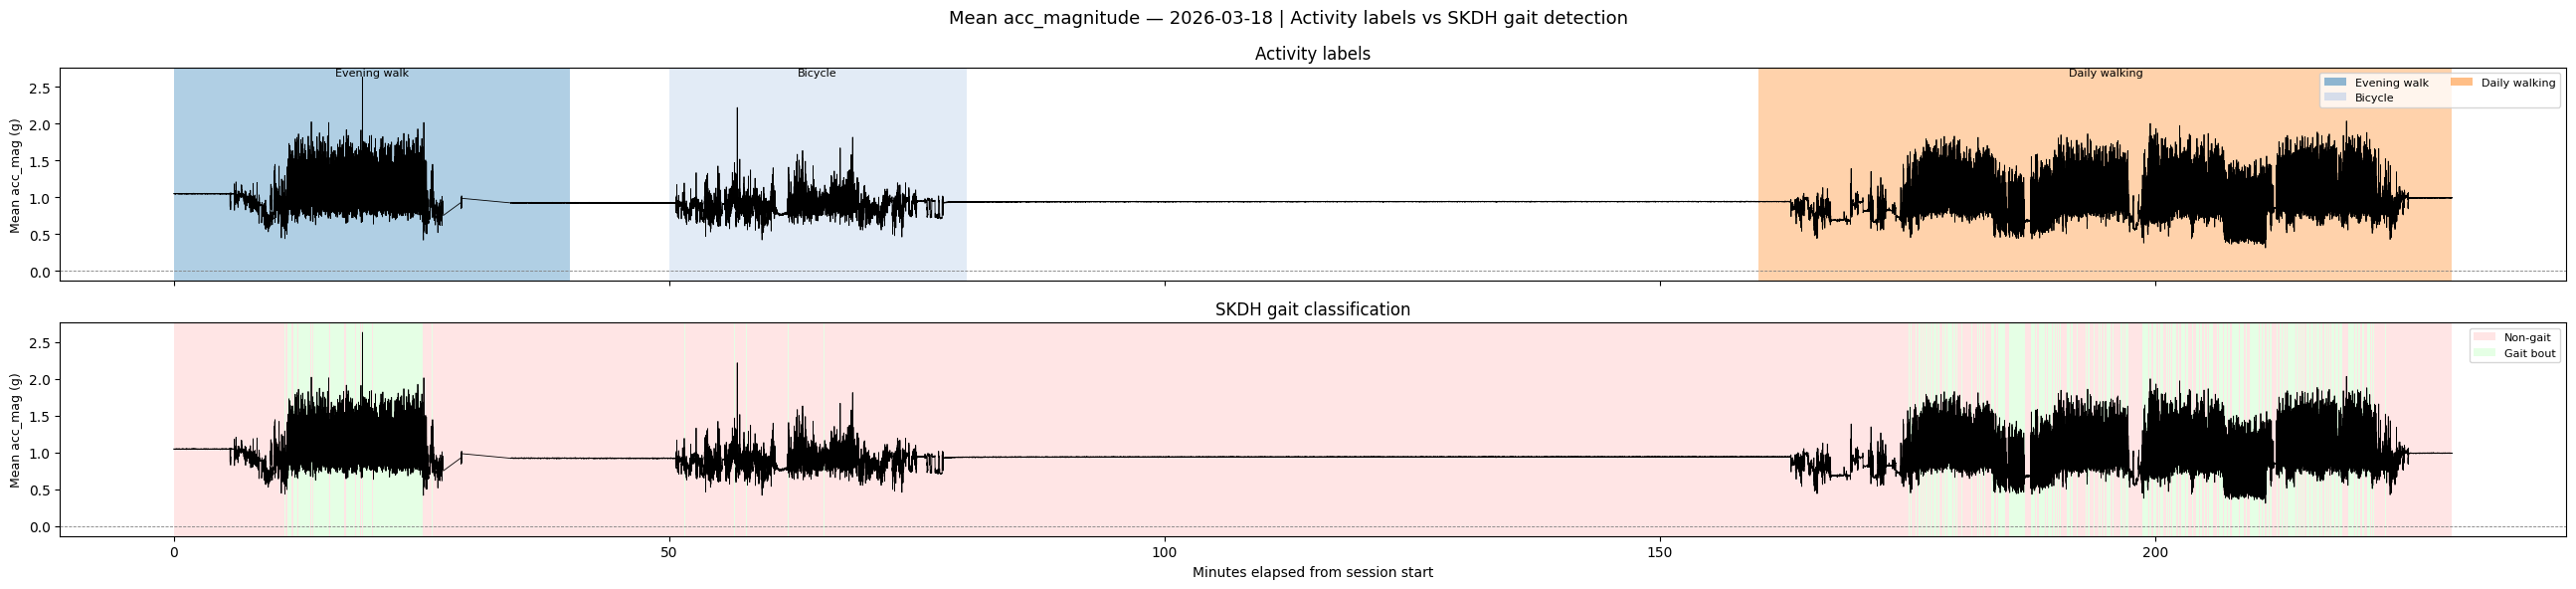

In [7]:
_COLORS_SKDH = {0: '#ffcccc', 1: '#ccffcc'}

def _min_elapsed(ts_series, t_ref):
    return (ts_series - t_ref).dt.total_seconds() / 60.0


plot_df_mean = df_mean[['Timestamp UTC', 'acc_magnitude']].dropna().copy()
plot_df_mean = plot_df_mean[
    (plot_df_mean['Timestamp UTC'] >= SESSION_START) &
    (plot_df_mean['Timestamp UTC'] <= SESSION_END)
].copy()
t_ref = plot_df_mean['Timestamp UTC'].iloc[0]
plot_df_mean['min_elapsed'] = _min_elapsed(plot_df_mean['Timestamp UTC'], t_ref)

if len(plot_df_mean) > 50_000:
    _stride = max(1, len(plot_df_mean) // 50_000)
    plot_df_mean_ds = plot_df_mean.iloc[::_stride].copy()
else:
    plot_df_mean_ds = plot_df_mean

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(26, 6), sharex=True)

# \u2500\u2500 Top panel: activity labels \u2500\u2500
for _, row in task_intervals.iterrows():
    s = (row['start_time'] - t_ref).total_seconds() / 60.0
    e = (row['end_time']   - t_ref).total_seconds() / 60.0
    ax1.axvspan(s, e, color=TASK_COLORS.get(row['task'], '#cccccc'), alpha=0.35, linewidth=0)
    ax1.text((s + e) / 2, 1.0, row['task'],
             transform=ax1.get_xaxis_transform(),
             ha='center', va='top', fontsize=8, clip_on=True)
ax1.plot(plot_df_mean_ds['min_elapsed'], plot_df_mean_ds['acc_magnitude'], color='black', lw=0.6)
ax1.axhline(0, color='0.5', ls='--', lw=0.6)
ax1.set_ylabel('Mean acc_mag (g)', fontsize=9)
ax1.set_title('Activity labels')
ax1.legend(
    handles=[mpatches.Patch(facecolor=TASK_COLORS[t], edgecolor='none', alpha=0.5, label=t)
             for t in _unique_tasks],
    loc='upper right', fontsize=8, ncol=2,
)

# \u2500\u2500 Bottom panel: SKDH detections \u2500\u2500
skdh_i = skdh_intervals_session.copy()
skdh_i['start_min'] = _min_elapsed(skdh_i['start_time'], t_ref)
skdh_i['end_min']   = _min_elapsed(skdh_i['end_time'],   t_ref)
for _, row in skdh_i.iterrows():
    ax2.axvspan(row['start_min'], row['end_min'],
                color=_COLORS_SKDH[row['prediction']], alpha=0.5, linewidth=0)
ax2.plot(plot_df_mean_ds['min_elapsed'], plot_df_mean_ds['acc_magnitude'], color='black', lw=0.6)
ax2.axhline(0, color='0.5', ls='--', lw=0.6)
ax2.set_ylabel('Mean acc_mag (g)', fontsize=9)
ax2.set_title('SKDH gait classification')
ax2.legend(
    handles=[
        mpatches.Patch(facecolor='#ffcccc', edgecolor='none', alpha=0.5, label='Non-gait'),
        mpatches.Patch(facecolor='#ccffcc', edgecolor='none', alpha=0.5, label='Gait bout'),
    ],
    loc='upper right', fontsize=8,
)
ax2.set_xlabel('Minutes elapsed from session start')

fig.suptitle('Mean acc_magnitude \u2014 2026-03-18 | Activity labels vs SKDH gait detection', fontsize=13)
plt.tight_layout()
plt.show()

## 6. AFD-CNN setup

In [8]:
import importlib
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
tf.logging.set_verbosity(tf.logging.ERROR)

FD_CNN_SRC   = '/home/ubuntu/git/FD-CNN/src'
FD_CNN_MODEL = '/home/ubuntu/git/FD-CNN/model/model.ckpt'

if FD_CNN_SRC not in sys.path:
    sys.path.insert(0, FD_CNN_SRC)

import cnn as cnn_module
importlib.reload(cnn_module)

# AFD-CNN output class mapping (MobiAct v2.0 label set)
FD_CLASS_LIST  = [0, 2, 3, 4, 5, 6, 7, 9]
FD_CLASS_NAMES = {
    0: 'Fall',
    2: 'Walk',
    3: 'Jog',
    4: 'Jump',
    5: 'Up-stairs',
    6: 'Down-stairs',
    7: 'Stand\u2192Sit',
    9: 'Sit\u2192Stand',
}
FD_COLORS = {
    0: '#e84040',  # Fall \u2014 red
    2: '#4a8fd4',  # Walk \u2014 blue
    3: '#56b56e',  # Jog \u2014 green
    4: '#e09c30',  # Jump \u2014 orange
    5: '#9b6bd4',  # Up-stairs \u2014 purple
    6: '#d47bb5',  # Down-stairs \u2014 pink
    7: '#888888',  # Stand\u2192Sit \u2014 grey
    9: '#aaaaaa',  # Sit\u2192Stand \u2014 light grey
}

# Build TensorFlow 1 graph and restore checkpoint
tf.reset_default_graph()
fd_x_ph            = tf.placeholder(tf.float32, [None, 1200], name='fd_input')
fd_logits, fd_keep = cnn_module.fall_net(fd_x_ph)
fd_probs_op        = tf.nn.softmax(fd_logits)

fd_saver = tf.train.Saver()
fd_sess  = tf.Session()
fd_saver.restore(fd_sess, FD_CNN_MODEL)
print('AFD-CNN model restored from', FD_CNN_MODEL)
print('Logits shape:', fd_logits.shape)

I0000 00:00:1776355348.877778   13929 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Instructions for updating:
non-resource variables are not supported in the long term
AFD-CNN model restored from /home/ubuntu/git/FD-CNN/model/model.ckpt
Logits shape: (?, 8)


E0000 00:00:1776355350.326388   13929 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
I0000 00:00:1776355350.330757   13929 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


## 7. Sliding-window scanning over all activity windows

We scan **every activity window** with a 200-sample sliding window at 100 Hz (= 2 s),
step = 25 samples (= 0.25 s).

Actigraph data is at 64 Hz \u2192 each window is resampled to 100 Hz (AFD-CNN training rate)
before preprocessing.

The AFD-CNN image format expects **1200 values**: accelerometer in the top half (rows 0\u20139)
and gyroscope in the bottom half (rows 10\u201319). Since the Actigraph records only
accelerometer data, the **gyroscope half is filled by copying the accelerometer data**.

In [9]:
# \u2500\u2500 Resampling & preprocessing constants \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
FD_FS_IN     = FS_ACTI   # 64 Hz  \u2014 Actigraph native rate
FD_FS_TRAIN  = 100       # Hz     \u2014 AFD-CNN training rate
FD_WIN_LEN   = 200       # samples at 100 Hz = 2 s
FD_STEP      = 25        # samples at 100 Hz = 0.25 s


def resample_bout(arr_g, fs_in, fs_out):
    """Polyphase resample (N, 3) g-unit array from fs_in to fs_out."""
    g = gcd(int(fs_in), int(fs_out))
    return resample_poly(arr_g, int(fs_out) // g, int(fs_in) // g, axis=0).astype(np.float32)


def g_to_uint8(arr_g):
    """
    Convert g-unit accelerometer data to [0, 255] matching AFD-CNN training preprocessing.

    Training formula (transform.py): (sensor_ms2 + data_move) * data_scale
    data_move=20, data_scale=6  \u2192  maps \u00b120 m/s\u00b2 \u2248 \u00b12 g to [0, 240].
    Actigraph data is in g \u2192 multiply by 9.81 to get m/s\u00b2 first.
    """
    return np.clip((arr_g * 9.81 + 20.0) * 6.0, 0.0, 255.0).astype(np.float32)


def extract_windows_from_segment(accel_64hz, timestamps_64hz, win_len, step, fs_in, fs_out):
    """
    Resample a (N, 3) segment from fs_in to fs_out, then scan with a sliding window.

    Each window: (win_len, 3) accelerometer \u2192 g_to_uint8 \u2192 flatten to (600,).
    The accelerometer half is then copied as a gyroscope proxy to produce the full
    (1200,) input expected by the AFD-CNN (top half = acc, bottom half = gyro proxy).

    Returns
    -------
    windows : (N_windows, 1200) float32 in [0, 255]
    meta    : list of dicts with 'win_idx', 'start_dt', 'end_dt'
    """
    if len(accel_64hz) == 0:
        return np.empty((0, 1200), dtype=np.float32), []

    scale = fs_out / fs_in
    arr_resampled = resample_bout(accel_64hz, fs_in, fs_out)  # (N_resamp, 3)
    arr_uint8     = g_to_uint8(arr_resampled)                  # (N_resamp, 3)

    windows, meta = [], []
    n_resamp = len(arr_resampled)

    for w_idx, off in enumerate(range(0, n_resamp - win_len + 1, step)):
        chunk = arr_uint8[off: off + win_len]          # (200, 3) \u2014 accelerometer
        flat  = chunk.flatten()                         # (600,)   \u2014 acc flattened
        windows.append(np.concatenate([flat, flat]))   # (1200,)  \u2014 acc + acc copy as gyro proxy

        # Map resampled sample indices back to original 64 Hz timestamps
        s_orig = min(int(off / scale),            len(timestamps_64hz) - 1)
        e_orig = min(int((off + win_len) / scale), len(timestamps_64hz) - 1)
        meta.append(dict(
            win_idx=w_idx,
            start_dt=timestamps_64hz[s_orig],
            end_dt=timestamps_64hz[e_orig],
        ))

    return np.array(windows, dtype=np.float32), meta


print(f'Sliding-window parameters:')
print(f'  Native Actigraph rate : {FD_FS_IN} Hz')
print(f'  Resample target rate  : {FD_FS_TRAIN} Hz')
print(f'  Window length         : {FD_WIN_LEN} samples @ {FD_FS_TRAIN} Hz = {FD_WIN_LEN/FD_FS_TRAIN:.2f} s')
print(f'  Step                  : {FD_STEP} samples @ {FD_FS_TRAIN} Hz = {FD_STEP/FD_FS_TRAIN:.3f} s')
print(f'  Image layout          : acc (rows 0\u20139) + acc copy as gyro proxy (rows 10\u201319)')

Sliding-window parameters:
  Native Actigraph rate : 64 Hz
  Resample target rate  : 100 Hz
  Window length         : 200 samples @ 100 Hz = 2.00 s
  Step                  : 25 samples @ 100 Hz = 0.250 s
  Image layout          : acc (rows 0–9) + acc copy as gyro proxy (rows 10–19)


In [10]:
# Scan ALL activity windows with AFD-CNN
# We use the Left Wrist (LW) X/Y/Z signal as the reference for the CNN,
# consistent with the wrist-worn deployment context.

all_windows  = []   # (1200,) flattened windows
all_meta     = []   # list of dicts with task, window info

for (win_str, task) in zip(classification_windows_2026_03_18, classification_tasks_2026_03_18):
    t0, tf = resolve_time_window(win_str)

    # Slice LW signal for this activity window
    seg = df_LW[
        (df_LW['Timestamp UTC'] >= t0) & (df_LW['Timestamp UTC'] <= tf)
    ][['Timestamp UTC', 'x', 'y', 'z']].dropna().copy()

    if seg.empty:
        print(f'  [{task}] \u2014 no data in window, skipping')
        continue

    accel_seg = seg[['x', 'y', 'z']].to_numpy(dtype=np.float32)
    ts_seg    = seg['Timestamp UTC'].to_numpy()

    wins, meta = extract_windows_from_segment(
        accel_seg, ts_seg,
        win_len=FD_WIN_LEN, step=FD_STEP,
        fs_in=FD_FS_IN, fs_out=FD_FS_TRAIN,
    )

    dur_s = (tf - t0).total_seconds()
    print(f'  [{task}]  {len(seg):,} samples ({dur_s:.0f} s)  \u2192  {len(wins)} windows')

    for m in meta:
        m['task'] = task
        m['win_start_tag'] = t0
        m['win_end_tag']   = tf

    all_windows.append(wins)
    all_meta.extend(meta)

if all_windows:
    fd_windows = np.vstack(all_windows)
else:
    fd_windows = np.empty((0, 1200), dtype=np.float32)

print(f'\nTotal windows across all activity windows: {len(fd_windows)}')
print(f'Input tensor shape : {fd_windows.shape}')
if len(fd_windows):
    print(f'Value range        : [{fd_windows.min():.1f}, {fd_windows.max():.1f}]')

  [Evening walk]  146,689 samples (2400 s)  →  9161 windows
  [Bicycle]  115,201 samples (1800 s)  →  7193 windows
  [Daily walking]  268,801 samples (4200 s)  →  16793 windows

Total windows across all activity windows: 33147
Input tensor shape : (33147, 1200)
Value range        : [0.0, 255.0]


In [11]:
# Run all windows through AFD-CNN (single forward pass in batches for memory safety)
BATCH_SIZE = 512

if len(fd_windows) == 0:
    print('No windows to classify.')
else:
    fd_probs_list = []
    for start in range(0, len(fd_windows), BATCH_SIZE):
        batch = fd_windows[start: start + BATCH_SIZE]
        probs = fd_sess.run(fd_probs_op, feed_dict={fd_x_ph: batch, fd_keep: 1.0})
        fd_probs_list.append(probs)

    fd_probs       = np.vstack(fd_probs_list)                          # (N, 8)
    fd_pred_idx    = np.argmax(fd_probs, axis=1)
    fd_pred_labels = [FD_CLASS_LIST[i]   for i in fd_pred_idx]
    fd_pred_names  = [FD_CLASS_NAMES[l]  for l in fd_pred_labels]
    fd_fall_probs  = fd_probs[:, FD_CLASS_LIST.index(0)]               # P(Fall)

    fd_results = pd.DataFrame(all_meta)
    fd_results['pred_label'] = fd_pred_labels
    fd_results['pred_name']  = fd_pred_names
    fd_results['fall_prob']  = fd_fall_probs
    fd_results['max_prob']   = fd_probs.max(axis=1)

    # Convert numpy datetime64 timestamps to pd.Timestamp
    fd_results['start_dt'] = pd.to_datetime(fd_results['start_dt'], utc=True)
    fd_results['end_dt']   = pd.to_datetime(fd_results['end_dt'],   utc=True)

    n_fall = (fd_results['pred_label'] == 0).sum()
    print(f'=== AFD-CNN results: {len(fd_results)} windows total ===')
    print(f'  Fall alerts : {n_fall} / {len(fd_results)} ({n_fall/len(fd_results):.1%})')
    print()
    print('Predicted class distribution across all activity windows:')
    print(fd_results['pred_name'].value_counts().to_string())

=== AFD-CNN results: 33147 windows total ===
  Fall alerts : 5627 / 33147 (17.0%)

Predicted class distribution across all activity windows:
pred_name
Down-stairs    27196
Fall            5627
Jog              239
Up-stairs         66
Walk              17
Sit→Stand          1
Jump               1


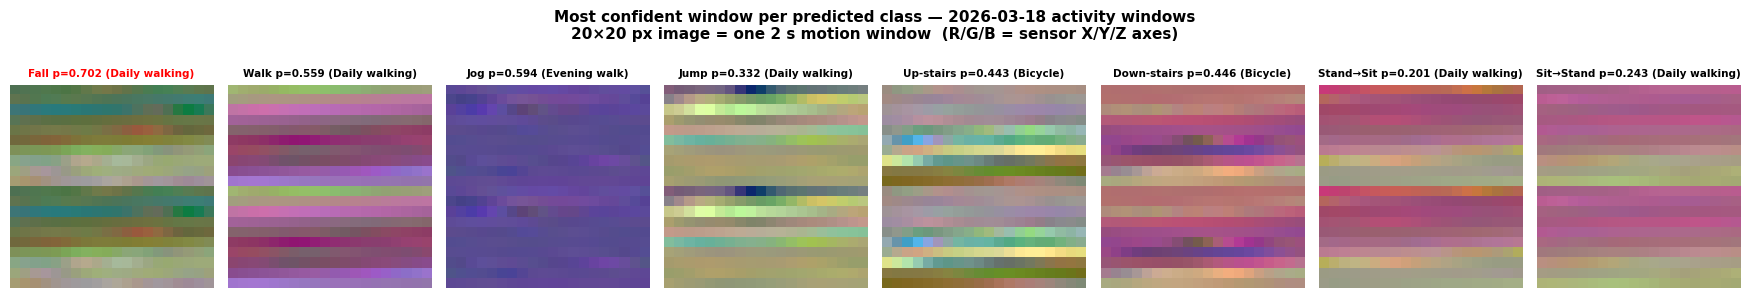

In [12]:
# \u2500\u2500 Best-detected window per predicted class (20\u00d720 RGB image, one per class) \u2500\u2500
# For each AFD-CNN class, find the window with the highest softmax probability
# and display it as a 20\u00d720 RGB image.

def to_image_acti(window_values):
    """Reshape 1200 flattened sensor values to a displayable 20\u00d720\u00d73 image."""
    img = np.array(window_values, dtype=np.float32).reshape(20, 20, 3)
    return img / 255.0   # scale to [0, 1] for imshow

n_cl = len(FD_CLASS_LIST)
fig, axes = plt.subplots(1, n_cl, figsize=(2.2 * n_cl, 3.2))

for ax, label in zip(axes, FD_CLASS_LIST):
    cls_idx   = FD_CLASS_LIST.index(label)
    best_idx  = int(np.argmax(fd_probs[:, cls_idx]))
    best_prob = fd_probs[best_idx, cls_idx]
    best_task = fd_results.iloc[best_idx]['task']

    img = to_image_acti(fd_windows[best_idx])
    ax.imshow(img)

    name  = FD_CLASS_NAMES[label]
    color = 'red' if label == 0 else 'black'
    ax.set_title(f'{name} p={best_prob:.3f} ({best_task})',
                 fontsize=7.5, color=color, fontweight='bold')
    ax.axis('off')
    if label == 0:
        for spine in ax.spines.values():
            spine.set_edgecolor('red')
            spine.set_linewidth(2)

fig.suptitle(
    'Most confident window per predicted class \u2014 2026-03-18 activity windows\n'
    '20\u00d720 px image = one 2 s motion window  (R/G/B = sensor X/Y/Z axes)',
    fontsize=11, fontweight='bold',
)
plt.tight_layout()
plt.show()

## 8. Results \u2014 per-activity summary

In [13]:
# Per-activity prediction breakdown
if len(fd_results) > 0:
    task_summary = (
        fd_results
        .groupby('task')
        .agg(
            n_windows=('pred_name', 'count'),
            fall_alerts=('pred_label', lambda x: (x == 0).sum()),
            mean_fall_prob=('fall_prob', 'mean'),
            max_fall_prob=('fall_prob', 'max'),
            top_class=('pred_name', lambda x: x.mode()[0]),
        )
        .reset_index()
    )
    task_summary['fall_alert_rate'] = task_summary['fall_alerts'] / task_summary['n_windows']

    # Preserve original activity order
    task_order = list(dict.fromkeys(classification_tasks_2026_03_18))
    task_summary['_order'] = task_summary['task'].map({t: i for i, t in enumerate(task_order)})
    task_summary = task_summary.sort_values('_order').drop(columns='_order')

    print('=== Per-activity AFD-CNN summary ===')
    print(task_summary.to_string(index=False, float_format='{:.3f}'.format))

=== Per-activity AFD-CNN summary ===
         task  n_windows  fall_alerts  mean_fall_prob  max_fall_prob   top_class  fall_alert_rate
 Evening walk       9161         2683           0.163          0.583 Down-stairs            0.293
      Bicycle       7193         2094           0.181          0.502 Down-stairs            0.291
Daily walking      16793          850           0.120          0.702 Down-stairs            0.051


## 9. Visualisation \u2014 P(Fall) over time per activity

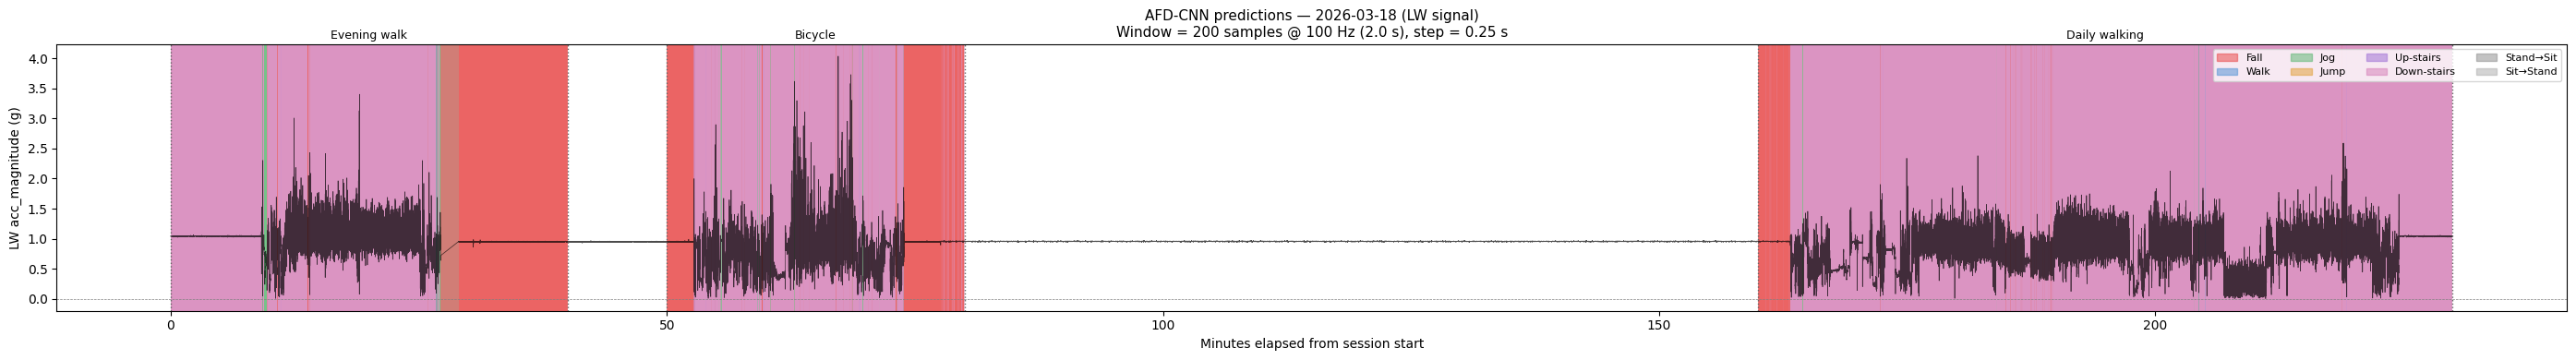

In [14]:
# Full-session timeline: LW acc_magnitude with AFD-CNN window shading
if len(fd_results) > 0:
    plot_lw = df_LW[['Timestamp UTC', 'acc_magnitude']].dropna().copy()
    plot_lw = plot_lw[
        (plot_lw['Timestamp UTC'] >= SESSION_START) &
        (plot_lw['Timestamp UTC'] <= SESSION_END)
    ].copy()
    t_ref_lw = plot_lw['Timestamp UTC'].iloc[0]
    plot_lw['min_elapsed'] = (plot_lw['Timestamp UTC'] - t_ref_lw).dt.total_seconds() / 60.0

    if len(plot_lw) > 80_000:
        plot_lw = plot_lw.iloc[::max(1, len(plot_lw) // 80_000)].copy()

    fig, ax = plt.subplots(figsize=(28, 4))
    ax.plot(plot_lw['min_elapsed'], plot_lw['acc_magnitude'], color='black', lw=0.5, alpha=0.7)

    for _, row in fd_results.iterrows():
        s = (row['start_dt'] - t_ref_lw).total_seconds() / 60.0
        e = (row['end_dt']   - t_ref_lw).total_seconds() / 60.0
        ax.axvspan(s, e, color=FD_COLORS.get(row['pred_label'], '#cccccc'), alpha=0.18, linewidth=0)

    # Mark activity window boundaries
    for _, row in task_intervals.iterrows():
        s = (row['start_time'] - t_ref_lw).total_seconds() / 60.0
        e = (row['end_time']   - t_ref_lw).total_seconds() / 60.0
        ax.axvline(s, color='0.4', ls=':', lw=1.0)
        ax.axvline(e, color='0.4', ls=':', lw=1.0)
        ax.text((s + e) / 2, 1.01, row['task'],
                transform=ax.get_xaxis_transform(),
                ha='center', va='bottom', fontsize=9)

    ax.axhline(0, color='0.5', ls='--', lw=0.5)
    ax.set_xlabel('Minutes elapsed from session start')
    ax.set_ylabel('LW acc_magnitude (g)')
    ax.set_title(
        f'AFD-CNN predictions \u2014 2026-03-18 (LW signal)\n'
        f'Window = {FD_WIN_LEN} samples @ {FD_FS_TRAIN} Hz ({FD_WIN_LEN/FD_FS_TRAIN:.1f} s), '
        f'step = {FD_STEP/FD_FS_TRAIN:.2f} s',
        fontsize=11,
    )
    legend_patches = [
        mpatches.Patch(color=FD_COLORS[l], alpha=0.5, label=FD_CLASS_NAMES[l])
        for l in FD_CLASS_LIST
    ]
    ax.legend(handles=legend_patches, fontsize=8, loc='upper right', ncol=4, framealpha=0.8)
    plt.tight_layout()
    plt.show()

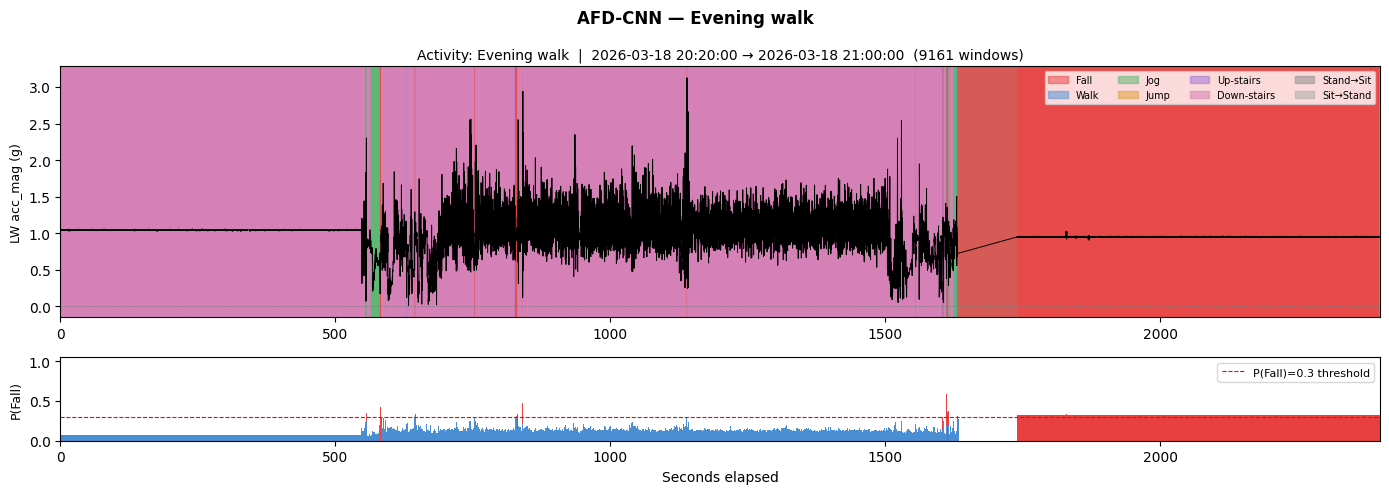

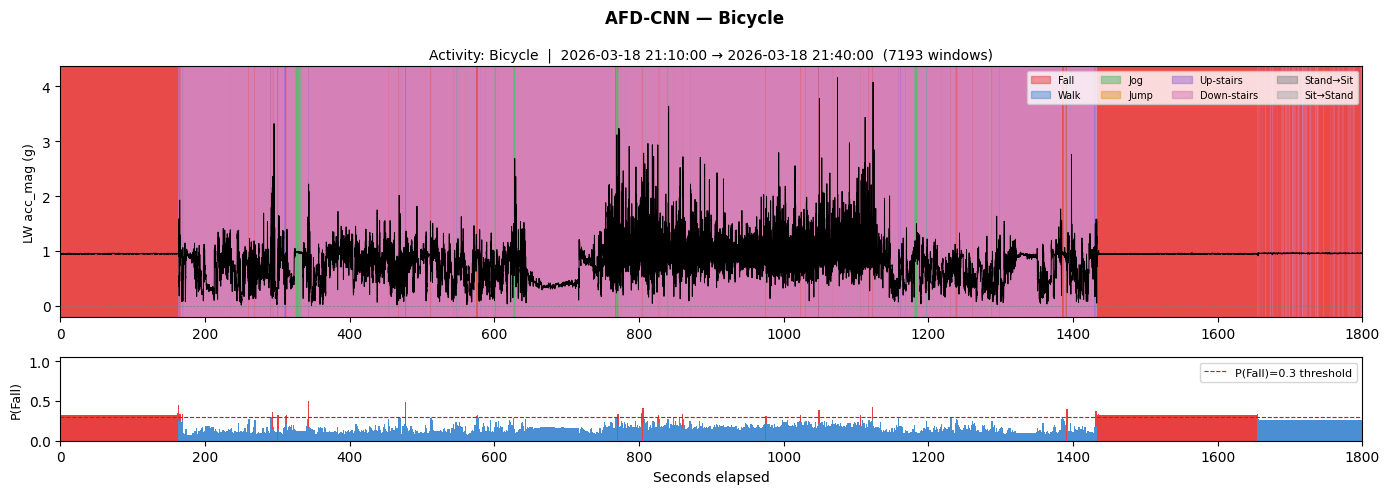

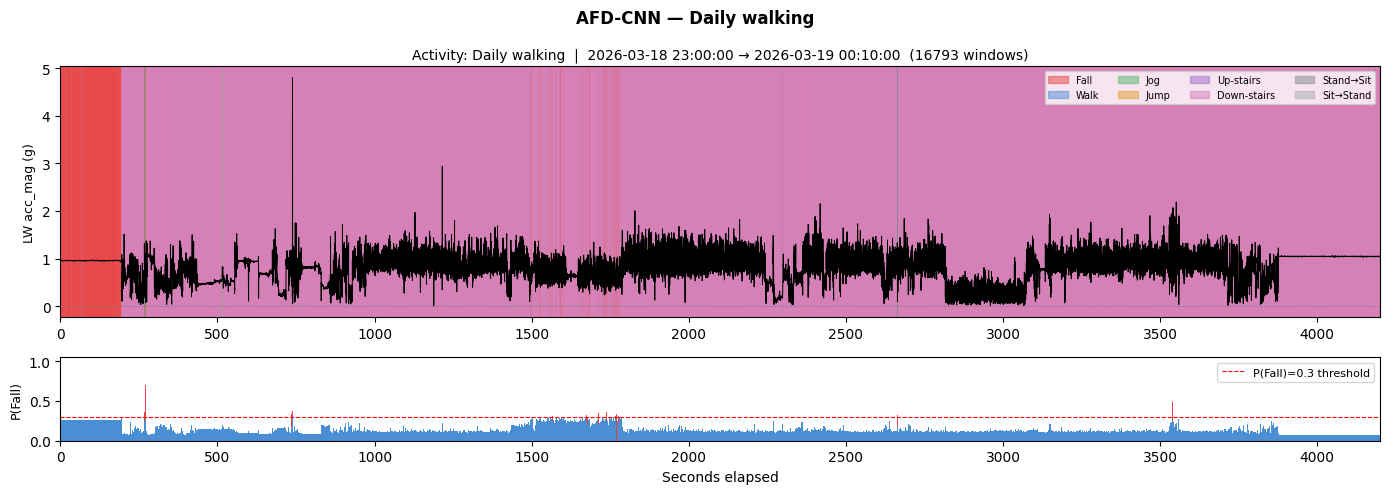

In [15]:
# Per-activity zoom: one figure per activity window showing LW signal + AFD-CNN predictions
if len(fd_results) > 0:
    for (win_str, task) in zip(classification_windows_2026_03_18, classification_tasks_2026_03_18):
        t0_z, tf_z = resolve_time_window(win_str)

        task_wins = fd_results[
            (fd_results['task'] == task) &
            (fd_results['start_dt'] >= t0_z) &
            (fd_results['end_dt']   <= tf_z)
        ].copy()
        if task_wins.empty:
            continue

        seg_lw = df_LW[
            (df_LW['Timestamp UTC'] >= t0_z) &
            (df_LW['Timestamp UTC'] <= tf_z)
        ][['Timestamp UTC', 'acc_magnitude']].dropna().copy()
        if seg_lw.empty:
            continue

        t_ref_z = seg_lw['Timestamp UTC'].iloc[0]
        seg_lw['sec_elapsed'] = (seg_lw['Timestamp UTC'] - t_ref_z).dt.total_seconds()
        if len(seg_lw) > 20_000:
            seg_lw = seg_lw.iloc[::max(1, len(seg_lw) // 20_000)].copy()

        fig, (ax_sig, ax_fall) = plt.subplots(
            2, 1, figsize=(14, 5),
            gridspec_kw={'height_ratios': [3, 1]},
        )

        # \u2500\u2500 Signal panel \u2500\u2500
        ax_sig.plot(seg_lw['sec_elapsed'], seg_lw['acc_magnitude'], color='black', lw=0.7)
        for _, row in task_wins.iterrows():
            s = (row['start_dt'] - t_ref_z).total_seconds()
            e = (row['end_dt']   - t_ref_z).total_seconds()
            ax_sig.axvspan(s, e,
                           color=FD_COLORS.get(row['pred_label'], '#cccccc'),
                           alpha=0.30, linewidth=0)
        ax_sig.axhline(0, color='0.5', ls='--', lw=0.5)
        ax_sig.set_ylabel('LW acc_mag (g)', fontsize=9)
        ax_sig.set_title(
            f'Activity: {task}  |  {win_str[0]} \u2192 {win_str[1]}  '
            f'({len(task_wins)} windows)',
            fontsize=10,
        )
        ax_sig.legend(
            handles=[mpatches.Patch(color=FD_COLORS[l], alpha=0.5, label=FD_CLASS_NAMES[l])
                     for l in FD_CLASS_LIST],
            fontsize=7, loc='upper right', ncol=4, framealpha=0.8,
        )

        # \u2500\u2500 P(Fall) bar panel \u2500\u2500
        x_sec = [(row['start_dt'] - t_ref_z).total_seconds() for _, row in task_wins.iterrows()]
        colors_bar = ['#e84040' if p >= 0.3 else '#4a8fd4' for p in task_wins['fall_prob']]
        ax_fall.bar(x_sec, task_wins['fall_prob'], width=FD_WIN_LEN / FD_FS_TRAIN * 0.9,
                    color=colors_bar, edgecolor='none', align='edge')
        ax_fall.axhline(0.3, color='red', ls='--', lw=0.8, label='P(Fall)=0.3 threshold')
        ax_fall.set_ylim(0, 1.05)
        ax_fall.set_ylabel('P(Fall)', fontsize=9)
        ax_fall.set_xlabel('Seconds elapsed')
        ax_fall.legend(fontsize=8, loc='upper right')

        # Sync x-axis limits
        x_min = seg_lw['sec_elapsed'].iloc[0]
        x_max = seg_lw['sec_elapsed'].iloc[-1]
        ax_sig.set_xlim(x_min, x_max)
        ax_fall.set_xlim(x_min, x_max)

        fig.suptitle(f'AFD-CNN \u2014 {task}', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

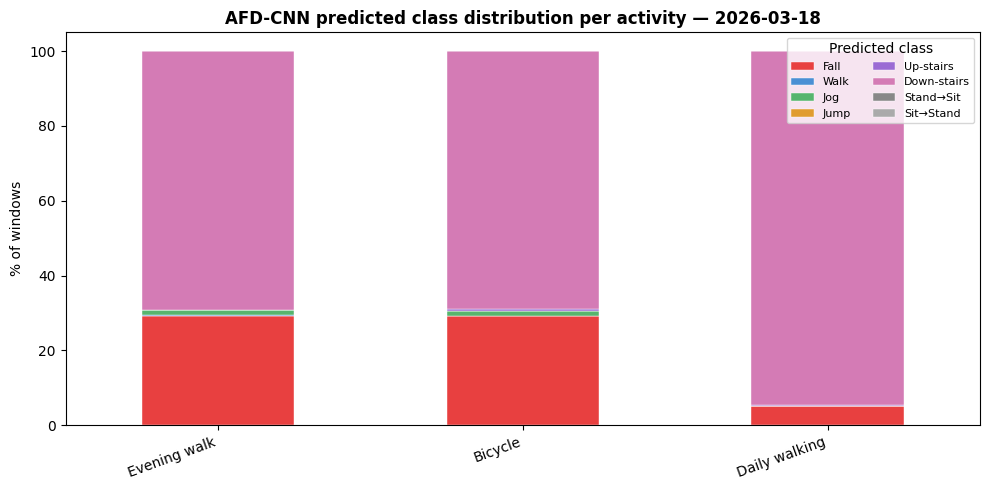


=== Predicted class distribution per activity (window counts) ===
pred_name      Fall  Walk  Jog  Jump  Up-stairs  Down-stairs  Stand→Sit  Sit→Stand
task                                                                              
Evening walk   2683     6  120     0         13         6339          0          0
Bicycle        2094     2   98     0         37         4961          0          1
Daily walking   850     9   21     1         16        15896          0          0


In [16]:
# Stacked bar: predicted class distribution per activity
if len(fd_results) > 0:
    _class_order = [FD_CLASS_NAMES[l] for l in FD_CLASS_LIST]
    _counts = (
        fd_results
        .groupby(['task', 'pred_name'])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=_class_order, fill_value=0)
    )
    # Preserve activity order
    task_order = list(dict.fromkeys(classification_tasks_2026_03_18))
    _counts = _counts.reindex([t for t in task_order if t in _counts.index])

    _pct = _counts.div(_counts.sum(axis=1), axis=0) * 100

    _class_colors = [FD_COLORS[l] for l in FD_CLASS_LIST]

    fig, ax = plt.subplots(figsize=(10, 5))
    _pct.plot(kind='bar', stacked=True, ax=ax, color=_class_colors,
              edgecolor='white', linewidth=0.3)
    ax.set_ylabel('% of windows', fontsize=10)
    ax.set_xlabel('')
    ax.set_xticklabels(_pct.index, rotation=20, ha='right', fontsize=10)
    ax.set_ylim(0, 105)
    ax.legend(title='Predicted class', fontsize=8, loc='upper right', ncol=2)
    ax.set_title('AFD-CNN predicted class distribution per activity \u2014 2026-03-18',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('\n=== Predicted class distribution per activity (window counts) ===')
    print(_counts.to_string())

## 10. SKDH walking bouts vs AFD-CNN predictions

In [17]:
# Cross-reference: for each SKDH-detected gait bout, show AFD-CNN window predictions
if n_bouts > 0 and len(fd_results) > 0:
    gait_starts_utc = pd.to_datetime(skdh_result_session['Gait Bout Start'], unit='s', utc=True)
    gait_stops_utc  = pd.to_datetime(skdh_result_session['Gait Bout Stop'],  unit='s', utc=True)

    print('=== AFD-CNN predictions inside SKDH gait bouts ===')
    for i, (gs, ge) in enumerate(zip(gait_starts_utc, gait_stops_utc)):
        dur = (ge - gs).total_seconds()

        # Find windows whose start falls inside this bout
        in_bout = fd_results[
            (fd_results['start_dt'] >= gs) & (fd_results['start_dt'] <= ge)
        ]
        if in_bout.empty:
            print(f'  Bout {i+1} ({dur:.0f} s): no AFD-CNN windows matched')
            continue

        n_fall_bout = (in_bout['pred_label'] == 0).sum()
        top_task    = in_bout['task'].mode()[0] if 'task' in in_bout.columns else '?'
        print(f'  Bout {i+1} ({dur:.0f} s | {gs.strftime("%H:%M:%S")}\u2013{ge.strftime("%H:%M:%S")}): '
              f'{len(in_bout)} windows  |  '
              f'Fall alerts: {n_fall_bout}  |  '
              f'Top class: {in_bout["pred_name"].mode()[0]}  |  '
              f'Activity tag: {top_task}')
else:
    print('No SKDH gait bouts detected or no AFD-CNN results available.')

=== AFD-CNN predictions inside SKDH gait bouts ===
  Bout 1 (3 s | 20:30:09–20:30:12): 13 windows  |  Fall alerts: 0  |  Top class: Down-stairs  |  Activity tag: Evening walk
  Bout 2 (3 s | 20:31:12–20:31:15): 13 windows  |  Fall alerts: 0  |  Top class: Down-stairs  |  Activity tag: Evening walk
  Bout 3 (24 s | 20:31:30–20:31:54): 97 windows  |  Fall alerts: 0  |  Top class: Down-stairs  |  Activity tag: Evening walk
  Bout 4 (18 s | 20:32:03–20:32:21): 73 windows  |  Fall alerts: 0  |  Top class: Down-stairs  |  Activity tag: Evening walk
  Bout 5 (3 s | 20:32:24–20:32:27): 13 windows  |  Fall alerts: 0  |  Top class: Down-stairs  |  Activity tag: Evening walk
  Bout 6 (69 s | 20:32:36–20:33:45): 277 windows  |  Fall alerts: 0  |  Top class: Down-stairs  |  Activity tag: Evening walk
  Bout 7 (6 s | 20:33:54–20:34:00): 25 windows  |  Fall alerts: 2  |  Top class: Down-stairs  |  Activity tag: Evening walk
  Bout 8 (90 s | 20:34:03–20:35:33): 361 windows  |  Fall alerts: 0  |  Top c

In [18]:
# Close TF session
fd_sess.close()
print('TF session closed.')

TF session closed.
